# Bonus: 2D Parzen Window (KDE) + Bayes Classifier


This notebook adapts the 1D Parzen lab to **two-dimensional measurements**:


- **x** = (sum of pixel intensities in the **left** half) − (sum in the **right** half)  

- **y** = (sum of pixel intensities in the **top** half) − (sum in the **bottom** half)


We estimate class-conditional densities using a **2D Gaussian kernel** with diagonal covariance


\[ K_h(\mathbf{u}) = \mathcal{N}(\mathbf{0}, h^2 I_2) \]


and then build a MAP Bayes classifier.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from pathlib import Path

# Make printouts deterministic
np.set_printoptions(precision=6, suppress=True)

# ---- Load data (same file as in the 1D lab) ----
# Adjust the path if needed
DATA_PATH = Path('data_33rpz_parzen.npz')
data = np.load(DATA_PATH, allow_pickle=True)
trn = data['trn'].item()
tst = data['tst'].item()

imgs_trn = trn['images']
labels_trn = np.squeeze(trn['labels']).astype(int)
imgs_tst = tst['images']
labels_tst = np.squeeze(tst['labels']).astype(int)

print('Train images:', imgs_trn.shape, '| Test images:', imgs_tst.shape)

Train images: (10, 10, 1800) | Test images: (10, 10, 200)


## 1) 2D measurement function

In [8]:
def compute_measurement_2d(imgs):
    """Return 2D measurements (x, y) for each image.
    x = sum(left) - sum(right)
    y = sum(top) - sum(bottom)
    imgs: numpy array (H, W, N)
    returns: (N, 2) array
    """
    assert imgs.ndim == 3, 'Expected (H, W, N)'
    H, W, N = imgs.shape
    # Sum over axes carefully with float64 for numeric stability
    # Left vs Right
    left = np.sum(imgs[:, :W//2, :], axis=(0,1), dtype=np.float64)
    right = np.sum(imgs[:, W//2:, :], axis=(0,1), dtype=np.float64)
    x = left - right
    # Top vs Bottom
    top = np.sum(imgs[:H//2, :, :], axis=(0,1), dtype=np.float64)
    bottom = np.sum(imgs[H//2:, :, :], axis=(0,1), dtype=np.float64)
    y = top - bottom
    return np.stack([x, y], axis=1)

# Compute 2D features for train/test
X_trn_2d = compute_measurement_2d(imgs_trn)
X_tst_2d = compute_measurement_2d(imgs_tst)
print('Train features:', X_trn_2d.shape, '| Test features:', X_tst_2d.shape)

# Split training by class
XA = X_trn_2d[labels_trn == 0]
XC = X_trn_2d[labels_trn == 1]
print('Class A:', XA.shape, '| Class C:', XC.shape)

Train features: (1800, 2) | Test features: (200, 2)
Class A: (1179, 2) | Class C: (621, 2)


## 2) 2D Parzen KDE

In [9]:
def parzen_2d(X_eval, X_train, h: float):
    """2D Gaussian Parzen KDE with diagonal covariance h^2 I.
    X_eval: (M,2), X_train: (N,2)
    returns: (M,) densities
    """
    X_eval = np.asarray(X_eval, dtype=np.float64)
    X_train = np.asarray(X_train, dtype=np.float64)
    # Gaussian kernel: (1/h^2) in 2D corresponds to |Sigma|^{-1/2} where Sigma = h^2 I -> (1/h^2)
    # We'll use multivariate_normal.pdf with cov=h^2*I2, then average over samples.
    cov = (h**2) * np.eye(2)
    mvn = multivariate_normal(mean=np.zeros(2), cov=cov)
    # Evaluate pairwise differences efficiently by broadcasting
    # For memory safety, process in chunks if needed
    M = X_eval.shape[0]
    N = X_train.shape[0]
    densities = np.zeros(M, dtype=np.float64)
    # Chunking to avoid huge temporary arrays on limited RAM
    chunk = 4096
    for start in range(0, M, chunk):
        stop = min(start+chunk, M)
        # (stop-start, N, 2)
        diffs = X_eval[start:stop, None, :] - X_train[None, :, :]
        vals = mvn.pdf(diffs)  # (stop-start, N)
        densities[start:stop] = np.mean(vals, axis=1)
    return densities

# Quick smoke test"
test_val = parzen_2d(X_tst_2d[:5], XA[:50], h=800.)
print('Parzen 2D sample densities:', test_val[:3])

Parzen 2D sample densities: [0. 0. 0.]


## 3) Visualize class-conditional densities (contours)

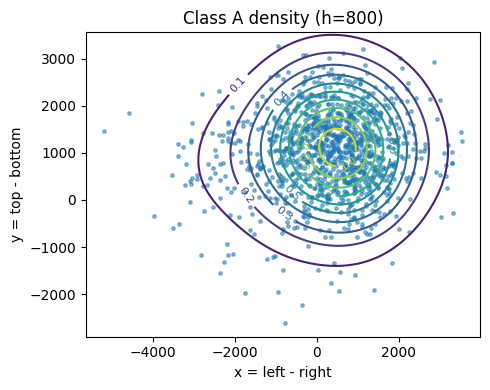

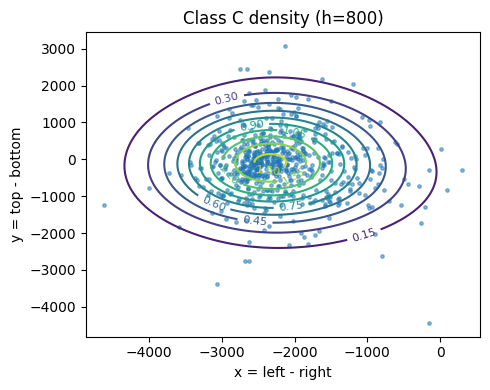

In [10]:
def plot_kde_contours(X_class, title, h=800., levels=10):
    X = X_class
    # Grid over data range
    margin = 0.05
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    span = maxs - mins
    mins = mins - margin*span
    maxs = maxs + margin*span
    gx = np.linspace(mins[0], maxs[0], 120)
    gy = np.linspace(mins[1], maxs[1], 120)
    GX, GY = np.meshgrid(gx, gy)
    G = np.column_stack([GX.ravel(), GY.ravel()])
    Z = parzen_2d(G, X, h=h).reshape(GX.shape)
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], s=6, alpha=0.5)
    CS = plt.contour(GX, GY, Z, levels=levels)
    plt.clabel(CS, inline=True, fontsize=8)
    plt.title(f"{title} (h={h:.0f})")
    plt.xlabel('x = left - right'); plt.ylabel('y = top - bottom')
    plt.tight_layout()

# Example plots (you can tweak h)
plot_kde_contours(XA, 'Class A density', h=800.)
plot_kde_contours(XC, 'Class C density', h=800.)

## 4) 10-fold cross-validation to choose $h$ (2D)

Best h (A): 350.0 | Best h (C): 300.0


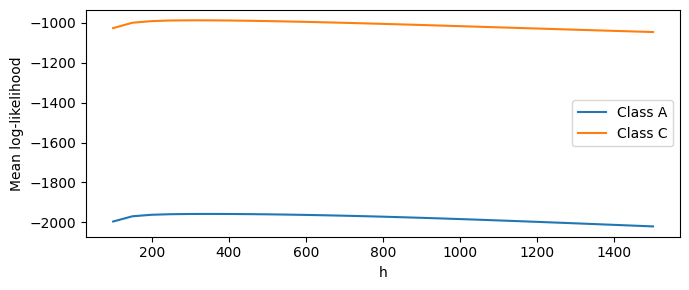

In [11]:
def crossval_indices(n, k=10, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, k)
    itrn, itst = [], []
    for i in range(k):
        itst.append(folds[i])
        itrn.append(np.concatenate([folds[j] for j in range(k) if j != i]))
    return itrn, itst


def mean_loglik_over_folds(X, h, k=10, seed=42, eps=1e-300):
    n = X.shape[0]
    itrn, itst = crossval_indices(n, k=k, seed=seed)
    s = 0.0
    for tr, te in zip(itrn, itst):
        p = parzen_2d(X[te], X[tr], h)
        s += np.sum(np.log(p + eps))
    return s / k

h_range = np.linspace(100., 1500., 29)
k_folds = 10

Lh_A = np.array([mean_loglik_over_folds(XA, h, k=k_folds, seed=42) for h in h_range])
Lh_C = np.array([mean_loglik_over_folds(XC, h, k=k_folds, seed=42) for h in h_range])

h_bestA = h_range[np.argmax(Lh_A)]
h_bestC = h_range[np.argmax(Lh_C)]
print('Best h (A):', h_bestA, '| Best h (C):', h_bestC)

plt.figure(figsize=(7,3))
plt.plot(h_range, Lh_A, label='Class A')
plt.plot(h_range, Lh_C, label='Class C')
plt.xlabel('h'); plt.ylabel('Mean log-likelihood'); plt.legend(); plt.tight_layout()

## 5) MAP Bayes classifier + accuracy

In [12]:
# Priors from training sizes
pi_A = XA.shape[0] / (XA.shape[0] + XC.shape[0])
pi_C = 1.0 - pi_A

def classify_bayes_parzen_2d(X_eval, XA, XC, pi_A, pi_C, hA, hC):
    pA = parzen_2d(X_eval, XA, hA)
    pC = parzen_2d(X_eval, XC, hC)
    logA = np.log(pA + 1e-300) + np.log(pi_A)
    logC = np.log(pC + 1e-300) + np.log(pi_C)
    return (logC > logA).astype(int)

y_pred = classify_bayes_parzen_2d(X_tst_2d, XA, XC, pi_A, pi_C, h_bestA, h_bestC)
acc = np.mean(y_pred == labels_tst)
print(f'2D Parzen + Bayes accuracy: {acc:.4f}')

2D Parzen + Bayes accuracy: 0.9450
